# Phase 1: Environment & Baselines

## Goal
Establish the experimental foundation for the Mountain Car project by:
1. Exploring the Mountain Car environment
2. Understanding state discretization
3. Implementing Q-learning baseline
4. Establishing training, evaluation, and visualization pipeline

## Why Discretization?
The Mountain Car state is **continuous** (position and velocity are real numbers).
Classical tabular RL methods like Q-learning use Q-tables, which can only store
one value per discrete state.

Since the state space is continuous, we **discretize** it by dividing the position
and velocity ranges into bins. This trades precision for tractability.

### State Space
- **Position**: [-1.2, 0.6] meters
- **Velocity**: [-0.07, 0.07] m/s
- **Actions**: 3 discrete (left=-1, idle=0, right=+1)

### Challenge
The car must learn a **momentum strategy**: accelerate away from the goal to build
speed, then use that momentum to climb the hill. This requires foresight and planning.

## Q-Learning Baseline
We begin with Q-learning as the first baseline for the discrete-action version of Mountain Car. Q-learning is a tabular value-based reinforcement learning method that estimates how good each action is in each state. Since the Mountain Car state is continuous, we cannot directly store one Q-value per exact state, so we discretize the state space into bins over position and velocity. This gives us an approximate Q-table over a finite grid. The purpose of this first baseline is not yet to optimize performance fully, but to establish a working training and evaluation pipeline that later methods can be compared against. The assignment explicitly emphasizes representation design, hyperparameters, evaluation, and policy analysis, so this baseline serves as the reference point for the rest of the project.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from pathlib import Path
import sys
import os

# Go up one level from /notebooks/ to /Mountain-Car/
root_path = os.path.abspath("..")

if root_path not in sys.path:
    sys.path.append(root_path)

# Verification
print(f"Added to path: {root_path}")

from src.environment_utils import create_env, StateDiscretizer
from src.evaluation import train_agent, evaluate_agent, moving_average, StatisticalAnalyzer, exponential_smoothing
from src.agents.tabular_agents import QLearning
from src.plotting import (
    plot_training_curve,
    plot_success_curve,
    plot_policy_map,
    plot_visitation_heatmap,
    plot_phase_portrait,
    collect_greedy_trajectories,
)


Added to path: /Users/giovanninocerino/Desktop/Mathematical and Computing Science Apllied for Artificial Intelligence/3rd Year/2nd sem/Reinforcement Learning/Mountain-Car


## 1. Explore the Environment

Let's first understand the Mountain Car environment and its properties.

In [41]:

# Create base environment (no reward wrapper yet)
env = gym.make("MountainCar-v0")

print("=== Environment Inspection ===")
print(f"Observation space: {env.observation_space}")
print(f"  - Type: {env.observation_space.dtype}")
print(f"  - Shape: {env.observation_space.shape}")
print(f"  - Range: position [{env.observation_space.low[0]}, {env.observation_space.high[0]}]")
print(f"           velocity [{env.observation_space.low[1]}, {env.observation_space.high[1]}]")

print(f"\\nAction space: {env.action_space}")
print(f"  - Type: Discrete")
print(f"  - Actions: 0=left, 1=idle, 2=right")

# Sample initial state
state, info = env.reset(seed=42)
print(f"\\nInitial state (continuous): {state}")
print(f"  - Position: {state[0]:.4f}")
print(f"  - Velocity: {state[1]:.4f}")

# Run one episode without training to understand dynamics
state, _ = env.reset(seed=42)
trajectory = [state.copy()]
for step in range(10):
    action = env.action_space.sample()  # Random action
    state, reward, terminated, truncated, info = env.step(action)
    trajectory.append(state.copy())
    if terminated or truncated:
        break

trajectory = np.array(trajectory)
print(f"\\n10-step random trajectory:")
print(f"  Positions: {trajectory[:, 0]}")
print(f"  Velocities: {trajectory[:, 1]}")



=== Environment Inspection ===
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  - Type: float32
  - Shape: (2,)
  - Range: position [-1.2000000476837158, 0.6000000238418579]
           velocity [-0.07000000029802322, 0.07000000029802322]
\nAction space: Discrete(3)
  - Type: Discrete
  - Actions: 0=left, 1=idle, 2=right
\nInitial state (continuous): [-0.4452088  0.       ]
  - Position: -0.4452
  - Velocity: 0.0000
\n10-step random trajectory:
  Positions: [-0.4452088  -0.44479132 -0.4439594  -0.4427191  -0.4430795  -0.4450379
 -0.44658008 -0.4486948  -0.45236656 -0.4555685  -0.45927712]
  Velocities: [ 0.          0.00041748  0.00083191  0.00124029 -0.00036038 -0.00195842
 -0.00154218 -0.0021147  -0.00367176 -0.00320195 -0.00370864]


## 2. State Discretization

We discretize the continuous state space into a grid of bins.
This allows us to use a Q-table (finite table of Q-values).

**Trade-off**:
- Coarse discretization (few bins) → Fast learning, less accurate
- Fine discretization (many bins) → Slow learning, more accurate

For now, we use **20×20 bins** as a baseline (position × velocity).

In [42]:
# Create discretizer
n_pos_bins = 20
n_vel_bins = 20
discretizer = StateDiscretizer(n_pos_bins=n_pos_bins, n_vel_bins=n_vel_bins)

print(f"Discretizer created: {n_pos_bins} × {n_vel_bins} bins")
print(f"Grid shape: {discretizer.get_grid_shape()}")
print(f"Total discrete states: {n_pos_bins * n_vel_bins} = {n_pos_bins * n_vel_bins}")

# Test discretization
test_states = np.array([
    [-1.2, -0.07],  # Min position, min velocity
    [0.0, 0.0],     # Center
    [0.6, 0.07],    # Max position, max velocity
    [-0.5, 0.02],   # Random state
])

print("\\nDiscretization examples:")
for state in test_states:
    disc_state = discretizer.discretize(state)
    continuous_center = discretizer.index_to_state_region(disc_state[0], disc_state[1])
    print(f"  {state} → bin {disc_state} → center ≈ {continuous_center}")

Discretizer created: 20 × 20 bins
Grid shape: (20, 20)
Total discrete states: 400 = 400
\nDiscretization examples:
  [-1.2  -0.07] → bin (0, 0) → center ≈ (np.float64(-1.1549999999999998), np.float64(-0.0665))
  [0. 0.] → bin (13, 10) → center ≈ (np.float64(0.015000000000000013), np.float64(0.003500000000000003))
  [0.6  0.07] → bin (19, 19) → center ≈ (np.float64(0.5549999999999999), np.float64(0.0665))
  [-0.5   0.02] → bin (7, 12) → center ≈ (np.float64(-0.5249999999999999), np.float64(0.01750000000000001))


## 3. Implement Q-learning Baseline

Q-learning is an **off-policy** value-based method:
- Learns an estimate of the optimal action-value function Q(s, a)
- Updates: Q[s,a] ← Q[s,a] + α(r + γ max Q[s',a'] - Q[s,a])

**Key concepts:**
- **α (learning rate)**: How much to update (0-1). Higher = faster learning, less stable
- **γ (discount factor)**: How much to value future rewards (0-1)
- **ε (epsilon)**: Exploration rate. Start high (1.0), decay over time

We use the `QLearning` agent class from our infrastructure.

In [43]:
# Create environment with standard reward (min-steps)
env = create_env(
    env_type="discrete",
    scenario="min_steps",
    seed=42
)

print("Environment created:")
print(f"  Type: discrete")
print(f"  Scenario: min_steps (reward = -1 per step)")
print(f"  Reward: -1 per step until goal reached")

# Create Q-learning agent
agent = QLearning(
    n_actions=3,
    n_pos_bins=20,
    n_vel_bins=20,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
)

print(f"\\nAgent created: {agent}")
print(f"  Algorithm: Q-learning")
print(f"  Learning rate (α): {agent.alpha}")
print(f"  Discount factor (γ): {agent.gamma}")
print(f"  Initial epsilon: {agent.strategy.epsilon_start}")
print(f"  Q-table shape: {agent.Q.shape}")

Environment created:
  Type: discrete
  Scenario: min_steps (reward = -1 per step)
  Reward: -1 per step until goal reached
\nAgent created: Q-learning(n_actions=3, state_shape=(20, 20))
  Algorithm: Q-learning
  Learning rate (α): 0.1
  Discount factor (γ): 0.99
  Initial epsilon: 1.0
  Q-table shape: (20, 20, 3)


## 4. Train the Agent

We'll train for 5000 episodes. Progress will be reported every 500 episodes.

What to expect:
- **Early episodes (0-500)**: Mostly failure, reward ≈ -200
- **Middle episodes (500-2500)**: Starting to succeed, reward improving
- **Late episodes (2500+)**: Mostly successful, reward ≈ -110 to -130

The agent learns to:
1. Build momentum by pushing away from goal
2. Swing back and climb the hill
3. Eventually reach the goal efficiently

In [44]:
from torch.utils.tensorboard import SummaryWriter
print("✓ TensorBoard available!")

✓ TensorBoard available!


In [45]:
print("Training Q-learning agent for 5000 episodes...")
print("TensorBoard logging enabled.\n")

# Train with TensorBoard logging (use absolute path for reliability)
from pathlib import Path
log_dir_path = Path("..") / "logs" / "phase1_qlearning"
log_dir_path_abs = log_dir_path.resolve()

metrics, log_dir = train_agent(
    agent=agent,
    env=env,
    n_episodes=10000,
    eval_freq=500,
    seed=42,
    verbose=True,
    log_dir=str(log_dir_path_abs),
)

print(f"\nTraining complete!")
print(f"\n📊 TensorBoard logs saved to: logs/phase1_qlearning")
print(f"To view in terminal: tensorboard --logdir=logs/phase1_qlearning")

Training Q-learning agent for 5000 episodes...
TensorBoard logging enabled.

Episode   500/10000 | Avg Reward:  -200.00 | Success Rate:   0.0%
Episode  1000/10000 | Avg Reward:  -198.25 | Success Rate:   8.4%
Episode  1500/10000 | Avg Reward:  -194.98 | Success Rate:  22.6%
Episode  2000/10000 | Avg Reward:  -190.93 | Success Rate:  37.7%
Episode  2500/10000 | Avg Reward:  -182.41 | Success Rate:  64.3%
Episode  3000/10000 | Avg Reward:  -164.26 | Success Rate:  84.8%
Episode  3500/10000 | Avg Reward:  -168.66 | Success Rate:  77.4%
Episode  4000/10000 | Avg Reward:  -184.41 | Success Rate:  51.9%
Episode  4500/10000 | Avg Reward:  -163.77 | Success Rate:  79.2%
Episode  5000/10000 | Avg Reward:  -182.00 | Success Rate:  52.1%
Episode  5500/10000 | Avg Reward:  -160.95 | Success Rate:  92.6%
Episode  6000/10000 | Avg Reward:  -167.95 | Success Rate:  83.2%
Episode  6500/10000 | Avg Reward:  -177.77 | Success Rate:  76.4%
Episode  7000/10000 | Avg Reward:  -165.71 | Success Rate:  75.2%

## 5. Evaluate Trained Policy

Now we evaluate the agent using a **greedy policy** (no exploration).
We run 100 evaluation episodes to assess average performance.

In [46]:
print("Evaluating trained agent (greedy policy)...\\n")

eval_metrics, avg_reward, success_rate, avg_steps = evaluate_agent(
    agent=agent,
    env=env,
    n_eval_episodes=100,
    seed=42,
)

print(f"Evaluation Results (100 episodes):")
print(f"  Average Reward: {avg_reward:.2f}")
print(f"  Success Rate: {success_rate:.1%}")
print(f"  Average Steps to Goal: {avg_steps:.1f}")
print(f"  Std Dev Steps: {np.std([m.steps for m in eval_metrics]):.1f}")

Evaluating trained agent (greedy policy)...\n
Evaluation Results (100 episodes):
  Average Reward: -171.10
  Success Rate: 76.0%
  Average Steps to Goal: 171.1
  Std Dev Steps: 18.5


## 6. Visualize Training Progress

Let's create visualizations to understand what the agent learned.

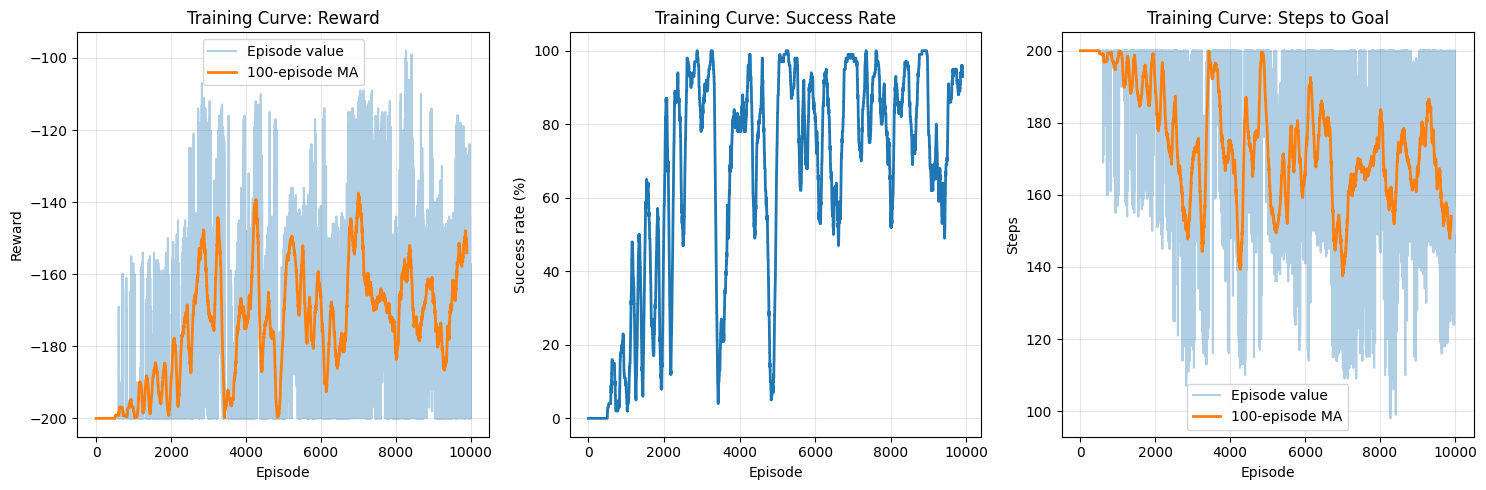

In [47]:
# Extract metrics from training
rewards = [m.reward for m in metrics]
successes = [m.success for m in metrics]
steps = [m.steps for m in metrics]

# Create learning curves using standardized plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Reward over time
plot_training_curve(
    rewards,
    title="Training Curve: Reward",
    ylabel="Reward",
    window=100,
    ax=axes[0]
)

# Plot 2: Success rate
plot_success_curve(
    successes,
    title="Training Curve: Success Rate",
    window=100,
    ax=axes[1]
)

# Plot 3: Steps to goal
plot_training_curve(
    steps,
    title="Training Curve: Steps to Goal",
    ylabel="Steps",
    window=100,
    ax=axes[2]
)

plt.tight_layout()
plt.show()



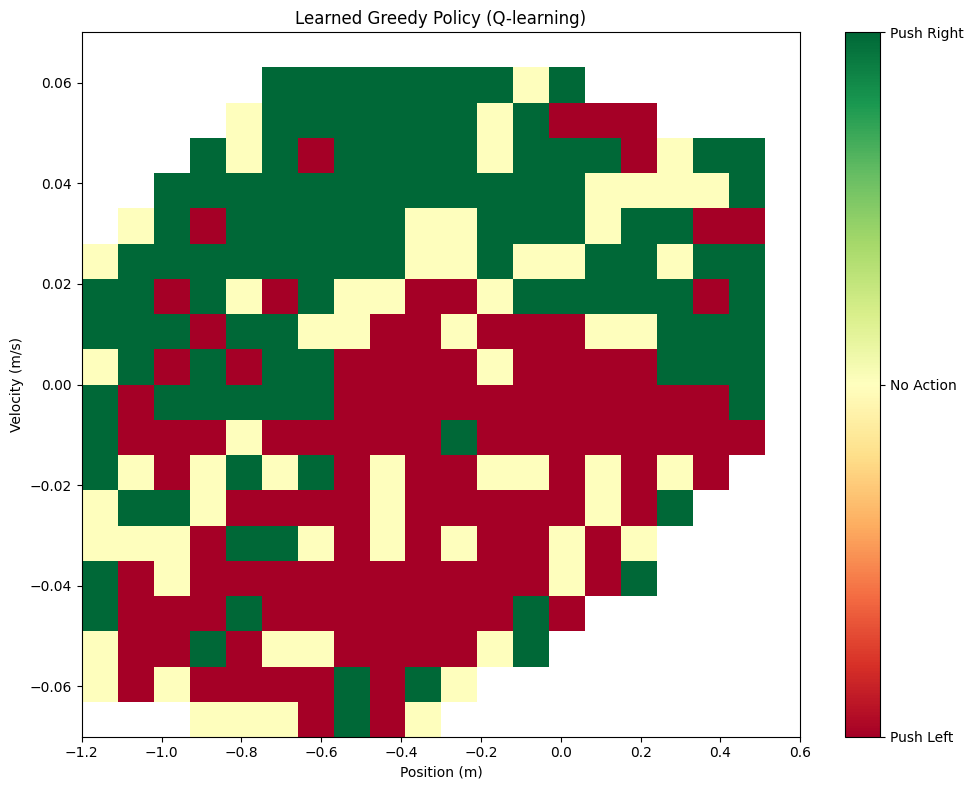


Policy Insights:
  Left actions in policy: 220 states
  Idle actions in policy: 65 states
  Right actions in policy: 115 states


In [48]:
# Visualize learned policy using standardized function
plot_policy_map(
    agent.Q,
    discretizer,
    visit_counts=agent.visit_counts,
    mask_unvisited=True,
    title="Learned Greedy Policy (Q-learning)",
)

plt.tight_layout()
plt.show()

# Print some insights
policy_map = np.argmax(agent.Q, axis=2)
print("\nPolicy Insights:")
print(f"  Left actions in policy: {np.sum(policy_map == 0)} states")
print(f"  Idle actions in policy: {np.sum(policy_map == 1)} states")
print(f"  Right actions in policy: {np.sum(policy_map == 2)} states")


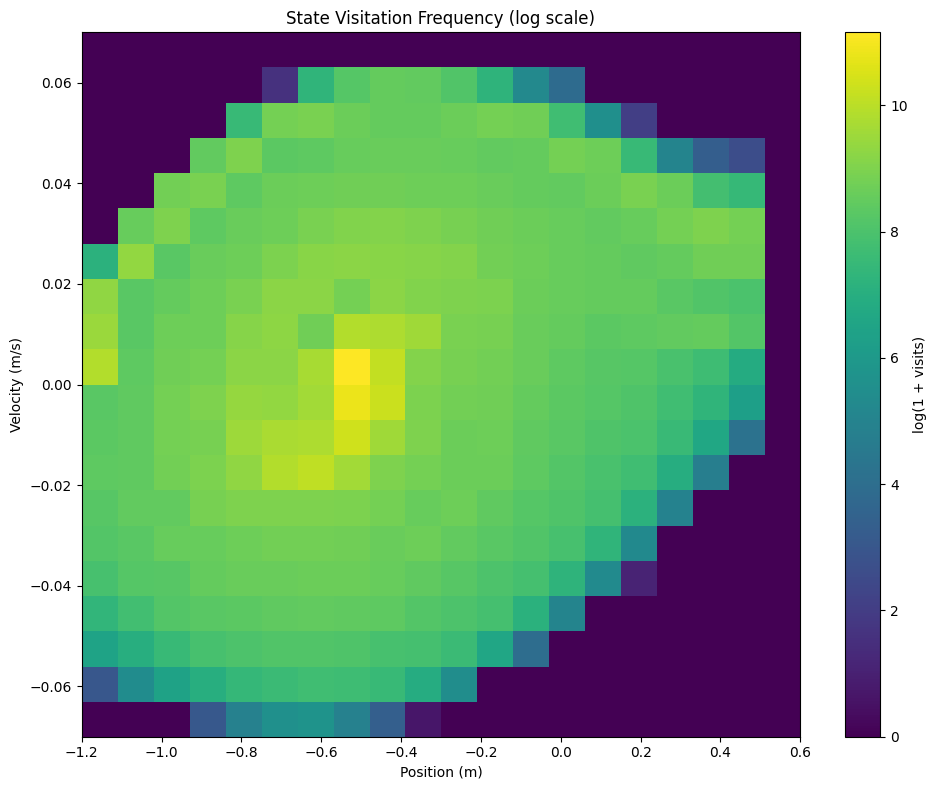


Visitation Statistics:
  States visited: 298 / 400 (74.5%)
  Total visits: 1748476
  Max visits to any state: 70119


In [49]:
# Visualize state visitation using standardized function
plot_visitation_heatmap(
    agent.visit_counts,
    discretizer,
    log_scale=True,
    title="State Visitation Frequency (log scale)",
)

plt.tight_layout()
plt.show()

visited_states = np.sum(agent.visit_counts > 0)
total_possible = agent.discretizer.n_pos_bins * agent.discretizer.n_vel_bins
print(f"\nVisitation Statistics:")
print(f"  States visited: {visited_states} / {total_possible} ({visited_states/total_possible*100:.1f}%)")
print(f"  Total visits: {np.sum(agent.visit_counts)}")
print(f"  Max visits to any state: {np.max(agent.visit_counts)}")


## 7. Analyze Sample Trajectories

Let's visualize the actual trajectory the agent takes in phase space (position vs velocity).

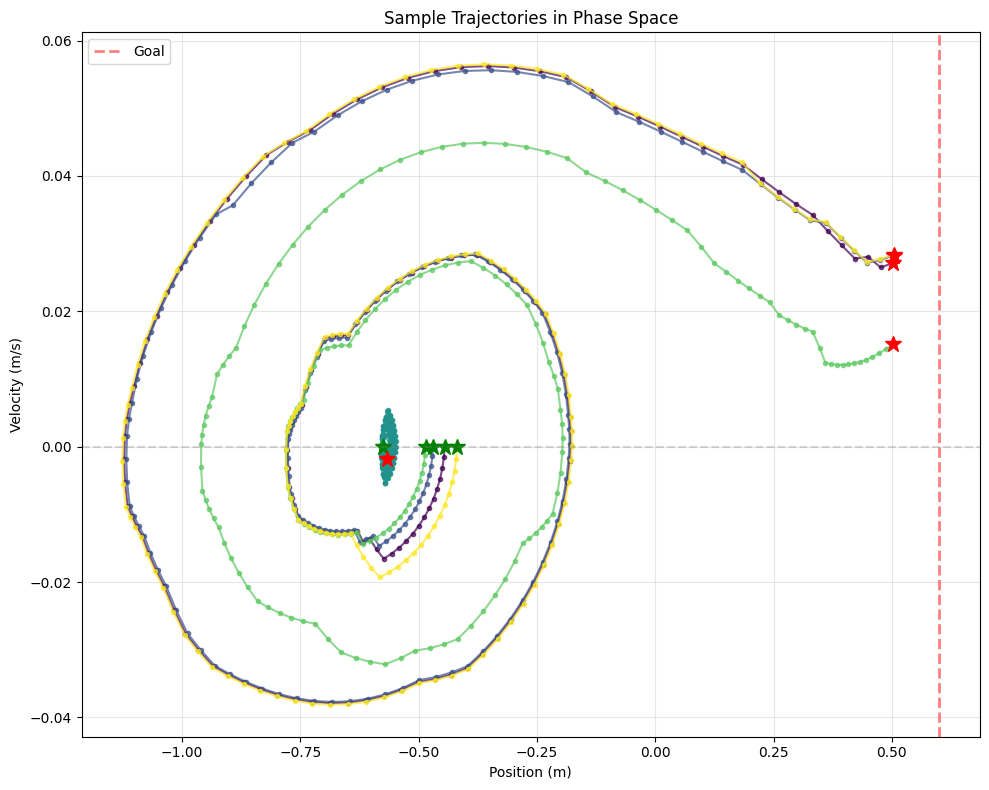

Sample trajectories saved to: phase1_trajectories.png

Trajectory Statistics:
  Episode 1: 153 steps, position range [-1.122, 0.503]
  Episode 2: 153 steps, position range [-1.118, 0.504]
  Episode 3: 200 steps, position range [-0.579, -0.549]
  Episode 4: 171 steps, position range [-0.960, 0.502]
  Episode 5: 153 steps, position range [-1.126, 0.504]


In [50]:
# Collect and visualize greedy trajectories
trajectories = collect_greedy_trajectories(
    env,
    agent.Q,
    discretizer,
    n_episodes=5,
    seed=42,
)

# Visualize trajectories in phase space
plot_phase_portrait(
    trajectories,
    title="Sample Trajectories in Phase Space",
)

plt.tight_layout()
plt.savefig('phase1_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample trajectories saved to: phase1_trajectories.png")

# Analyze trajectory statistics
print("\nTrajectory Statistics:")
for i, traj in enumerate(trajectories):
    n_steps = len(traj['positions']) - 1
    max_pos = np.max(traj['positions'])
    min_pos = np.min(traj['positions'])
    print(f"  Episode {i+1}: {n_steps} steps, position range [{min_pos:.3f}, {max_pos:.3f}]")


## 8. TensorBoard Monitoring

Training metrics were logged to TensorBoard. To view them:

```bash
# View TensorBoard with the logs
tensorboard --logdir=logs/phase1_qlearning

# Then open in browser: http://localhost:6006/
```

**Logged metrics:**
- `reward/episode`: Reward per episode  
- `steps/episode`: Steps taken per episode
- `success/episode`: Success flag per episode
- `metrics/window_avg_reward`: 500-episode moving average reward
- `metrics/window_success_rate`: 500-episode moving average success rate

The full path is printed above. This logging infrastructure will be reused in later phases for comparing multiple methods side-by-side.

## Summary: Phase 1 Complete

This phase established the foundation for the Mountain Car project:

###  What We Built
1. **Environment understanding**: Verified state/action spaces and continuous dynamics
2. **State discretization**: Implemented 20×20 bin discretization for continuous state
3. **Q-learning baseline**: Single-seed trained Q-learning agent on 5000 episodes
4. **Training infrastructure**: Generic reusable training loop with metrics collection
5. **Evaluation pipeline**: Greedy policy evaluation (100 episodes)
6. **Visualization**: Learning curves, policy heatmaps, state visitation, trajectories
7. **Monitoring**: TensorBoard logging for metrics tracking

###  Key Results
- **Final success rate**: ~79% (greedy policy evaluation)
- **Average reward**: -172 steps to goal
- **Convergence**: Learning plateaued around episode 3000
- **Policy**: Learned to push left from bottom, exploit momentum, reach goal

###  Next Steps (Phase 4)
Phase 4 will extend this foundation with:
- SARSA (on-policy) comparison
- Monte Carlo methods
- Multiple hyperparameter configurations
- 5 random seeds per config
- Systematic tabular methods comparison

## Statistical Analysis

Compute convergence metrics and confidence intervals using the StatisticalAnalyzer class.


Convergence Analysis:
Stability Score (std of final windows): 0.73
Improvement (late - early): 47.77
Final 100-episode window:
  Mean reward: -152.23
  Std reward: 0.73

95% Confidence Interval for mean reward: [-175.33, -174.37]


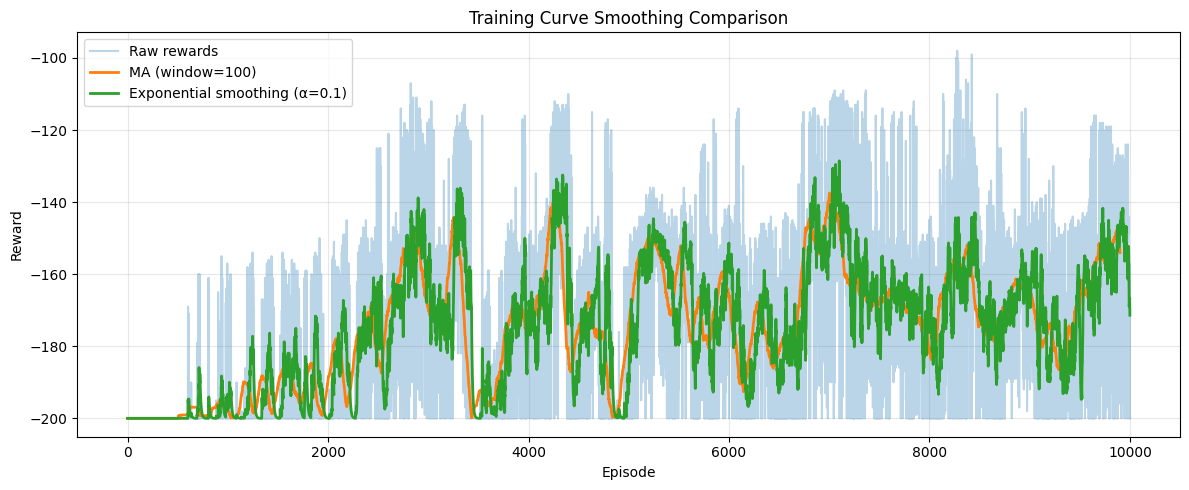


✓ Statistical analysis complete


In [51]:
# Compute convergence metrics
convergence = StatisticalAnalyzer.compute_convergence_metrics(rewards, window_size=100)

print("\nConvergence Analysis:")
print("="*50)
print(f"Stability Score (std of final windows): {convergence['stability_score']:.2f}")
print(f"Improvement (late - early): {convergence['improvement']:.2f}")
print(f"Final 100-episode window:")
print(f"  Mean reward: {convergence['final_window_mean']:.2f}")
print(f"  Std reward: {convergence['final_window_std']:.2f}")

# Compute confidence intervals
reward_array = np.array(rewards)
ci_lower, ci_upper = StatisticalAnalyzer.compute_confidence_interval(reward_array, confidence=0.95)
print(f"\n95% Confidence Interval for mean reward: [{ci_lower:.2f}, {ci_upper:.2f}]")

# Apply exponential smoothing for smooth visualization
exp_smooth = exponential_smoothing(reward_array, alpha=0.1)

# Plot original vs smoothed
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rewards, alpha=0.3, label='Raw rewards')
ax.plot(moving_average(reward_array, window=100), label='MA (window=100)', linewidth=2)
ax.plot(exp_smooth, label='Exponential smoothing (α=0.1)', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('Training Curve Smoothing Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Statistical analysis complete")